## Importing Libraries

In [1]:
import fiona
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape, Point
from shapely import wkb
import statsmodels.api as sm

## Suburb INFO

In [2]:
records = list(fiona.open("VIC_LOC_GDA94/vic_localities.shp"))

names = []
wkbs = []
for r in records:
    names.append(r["properties"]["LOC_NAME"])
    wkbs.append(shape(r["geometry"]).wkb)

suburb_df = gpd.GeoDataFrame(
    {"suburb": names, "geometry": [wkb.loads(x) for x in wkbs]},
    crs="EPSG:4283"
)

In [3]:
suburb_df.head()

,suburb,geometry
0,Abbeyard,"POLYGON ((146.65061 -36.94497, 146.68448 -36.9..."
1,Abbotsford,"POLYGON ((144.99137 -37.80961, 144.99253 -37.8..."
2,Aberfeldie,"POLYGON ((144.88853 -37.75548, 144.88853 -37.7..."
3,Aberfeldy,"POLYGON ((146.35535 -37.69946, 146.35751 -37.6..."
4,Acheron,"POLYGON ((145.63799 -37.28418, 145.64233 -37.2..."


## Stops INFO

In [4]:
stops_df = gpd.read_file("public_transport_stops.geojson")
stops_df = stops_df.to_crs(suburb_df.crs)

In [5]:
stops_df.head()

,STOP_ID,STOP_NAME,MODE,geometry
0,17204,Wallan Station,REGIONAL TRAIN,POINT (145.00537 -37.41686)
1,19980,Melton Station,REGIONAL TRAIN,POINT (144.57222 -37.70336)
2,19981,Rockbank Station,REGIONAL TRAIN,POINT (144.65071 -37.72919)
3,19982,Deer Park Station,REGIONAL TRAIN,POINT (144.77083 -37.77727)
4,19998,Sunbury Station,REGIONAL TRAIN,POINT (144.72803 -37.57915)


In [6]:
suburb_stop_df = gpd.sjoin(stops_df, suburb_df, how="left", predicate="within")
suburb_stop_df.head()

,STOP_ID,STOP_NAME,MODE,geometry,index_right,suburb
0,17204,Wallan Station,REGIONAL TRAIN,POINT (145.00537 -37.41686),2686.0,Wallan
1,19980,Melton Station,REGIONAL TRAIN,POINT (144.57222 -37.70336),1658.0,Melton South
2,19981,Rockbank Station,REGIONAL TRAIN,POINT (144.65071 -37.72919),2204.0,Rockbank
3,19982,Deer Park Station,REGIONAL TRAIN,POINT (144.77083 -37.77727),735.0,Deer Park
4,19998,Sunbury Station,REGIONAL TRAIN,POINT (144.72803 -37.57915),2412.0,Sunbury


In [7]:
suburb_stop_df = (
    suburb_stop_df
    .groupby(["suburb", "MODE"])
    .agg(stop_count=("STOP_NAME", "nunique"))
    .reset_index()
)
suburb_stop_df

,suburb,MODE,stop_count
0,Abbotsford,METRO BUS,12
1,Abbotsford,METRO TRAIN,18
2,Abbotsford,METRO TRAM,6
3,Aberfeldie,METRO BUS,15
4,Acheron,METRO BUS,1
...,...,...,...
1768,Yarroweyah,REGIONAL COACH,1
1769,Yea,REGIONAL COACH,1
1770,Yendon,REGIONAL COACH,1
1771,Yinnar,REGIONAL BUS,3


## Schools INFO

In [8]:
schools_df = pd.read_csv("dv402-SchoolLocations2025.csv")
schools_df = gpd.GeoDataFrame(
    schools_df,
    geometry=gpd.points_from_xy(schools_df["X"], schools_df["Y"]),
    crs="EPSG:4326"
)
schools_df = schools_df.to_crs(suburb_df.crs)
schools_df.head()

,Education_Sector,Entity_Type,School_No,School_Name,School_Type,School_Status,Address_Line_1,Address_Line_2,Address_Town,Address_State,...,Postal_Postcode,Full_Phone_No,Region,Area,LGA_ID,LGA_Name,LGA_TYPE,X,Y,geometry
0,Catholic,2,20,Parade College,Secondary,O,1436 Plenty Road,NaN,BUNDOORA,VIC,...,3083,03 9468 3300,NORTH-WESTERN VICTORIA,North Eastern Melbourne,66,Banyule (C),Metro,145.066978,-37.690178,POINT (145.06698 -37.69018)
1,Catholic,2,25,Simonds Catholic College,Secondary,O,273 Victoria Street,NaN,WEST MELBOURNE,VIC,...,3003,03 9321 9200,SOUTH-WESTERN VICTORIA,Western Melbourne,460,Melbourne (C),Metro,144.952883,-37.805971,POINT (144.95288 -37.80597)
2,Catholic,2,26,St Mary’s College Melbourne,Secondary,O,11 Westbury Street,NaN,ST KILDA EAST,VIC,...,3182,03 9529 6611,SOUTH-EASTERN VICTORIA,Bayside Peninsula,590,Port Phillip (C),Metro,144.997001,-37.859365,POINT (144.997 -37.85936)
3,Catholic,2,28,St Patrick's College Ballarat,Secondary,O,1431 Sturt Street,NaN,BALLARAT,VIC,...,3350,03 5331 1688,SOUTH-WESTERN VICTORIA,Central Highlands,57,Ballarat (C),Non Metro,143.831558,-37.559711,POINT (143.83156 -37.55971)
4,Catholic,2,29,St Patrick's School,Primary,O,119 Drummond Street South,NaN,BALLARAT,VIC,...,3350,03 5332 7680,SOUTH-WESTERN VICTORIA,Central Highlands,57,Ballarat (C),Non Metro,143.847147,-37.564397,POINT (143.84715 -37.5644)


In [9]:
suburb_schools_df = gpd.sjoin(schools_df, suburb_df, how="left", predicate="within")
suburb_schools_df.head()

,Education_Sector,Entity_Type,School_No,School_Name,School_Type,School_Status,Address_Line_1,Address_Line_2,Address_Town,Address_State,...,Region,Area,LGA_ID,LGA_Name,LGA_TYPE,X,Y,geometry,index_right,suburb
0,Catholic,2,20,Parade College,Secondary,O,1436 Plenty Road,NaN,BUNDOORA,VIC,...,NORTH-WESTERN VICTORIA,North Eastern Melbourne,66,Banyule (C),Metro,145.066978,-37.690178,POINT (145.06698 -37.69018),403,Bundoora
1,Catholic,2,25,Simonds Catholic College,Secondary,O,273 Victoria Street,NaN,WEST MELBOURNE,VIC,...,SOUTH-WESTERN VICTORIA,Western Melbourne,460,Melbourne (C),Metro,144.952883,-37.805971,POINT (144.95288 -37.80597),2784,West Melbourne
2,Catholic,2,26,St Mary’s College Melbourne,Secondary,O,11 Westbury Street,NaN,ST KILDA EAST,VIC,...,SOUTH-EASTERN VICTORIA,Bayside Peninsula,590,Port Phillip (C),Metro,144.997001,-37.859365,POINT (144.997 -37.85936),2364,St Kilda East
3,Catholic,2,28,St Patrick's College Ballarat,Secondary,O,1431 Sturt Street,NaN,BALLARAT,VIC,...,SOUTH-WESTERN VICTORIA,Central Highlands,57,Ballarat (C),Non Metro,143.831558,-37.559711,POINT (143.83156 -37.55971),1946,Newington
4,Catholic,2,29,St Patrick's School,Primary,O,119 Drummond Street South,NaN,BALLARAT,VIC,...,SOUTH-WESTERN VICTORIA,Central Highlands,57,Ballarat (C),Non Metro,143.847147,-37.564397,POINT (143.84715 -37.5644),111,Ballarat Central


In [10]:
suburb_schools_df = (
    suburb_schools_df
    .groupby(["suburb", "School_Type"])
    .agg(school_count=("Address_Line_1", "nunique"))
    .reset_index()
)
suburb_schools_df

,suburb,School_Type,school_count
0,Abbotsford,Pri/Sec,1
1,Abbotsford,Primary,1
2,Aberfeldie,Primary,2
3,Aberfeldie,Secondary,1
4,Aintree,Primary,1
...,...,...,...
1403,Yea,Secondary,1
1404,Yering,Primary,1
1405,Yinnar,Primary,1
1406,Yinnar South,Primary,1


## Forecast Rent INFO

In [13]:
forecast_df = pd.read_csv("historical_forcast_cleaned.csv")
forecast_df["timestamp"] = pd.to_datetime(forecast_df["timestamp"])
forecast_df = forecast_df.sort_values(["region", "suburb", "type", "timestamp"])

latest_df = (
    forecast_df.groupby(["region", "suburb", "type"])
      .apply(lambda g: g.sort_values("timestamp").iloc[-1])
      .reset_index(drop=True)
)

latest_df = latest_df.rename(columns={"Median": "Latest_Median"})
latest_df = latest_df[["region", "suburb", "type", "timestamp", "Latest_Median"]]


def forecast_next(g):
    if len(g) < 3:
        return g["Median"].iloc[-1]

    g = g.groupby("timestamp")["Median"].median().sort_index()
    y = g.asfreq("Q")

    if y.notna().sum() == 0:
        return g.dropna().iloc[-1]

    model = sm.tsa.statespace.SARIMAX(
        y,
        order=(1, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    forecast = model.get_forecast(steps=1).predicted_mean.iloc[0]
    return float(forecast)


region_type_forecast_df = (
    forecast_df.groupby(["region", "type"])
        .apply(forecast_next)
        .reset_index(name="Forecasted_Next_Quarter")
)

forecast_df = latest_df.merge(
    region_type_forecast_df,
    on=["region", "type"],
    how="left"
)

forecast_df = forecast_df.rename(columns={"type": "Housing_Type"})
forecast_df["Forecasted_Next_Quarter"] = forecast_df["Forecasted_Next_Quarter"].round().astype(int)
forecast_df.head()

/var/folders/jf/rtxx_ysd6zxdj8lzpl5gbqyc0000gp/T/ipykernel_33549/2580218042.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("timestamp").iloc[-1])
/var/folders/jf/rtxx_ysd6zxdj8lzpl5gbqyc0000gp/T/ipykernel_33549/2580218042.py:20: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  y = g.asfreq("Q")
/var/folders/jf/rtxx_ysd6zxdj8lzpl5gbqyc0000gp/T/ipykernel_33549/2580218042.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the 

,region,suburb,Housing_Type,timestamp,Latest_Median,Forecasted_Next_Quarter
0,Ballarat,Ballarat,1 bedroom flat,2025-03-01,280,280
1,Ballarat,Ballarat,2 bedroom flat,2025-03-01,350,348
2,Ballarat,Ballarat,2 bedroom house,2025-03-01,360,360
3,Ballarat,Ballarat,3 bedroom flat,2025-03-01,400,394
4,Ballarat,Ballarat,3 bedroom house,2025-03-01,400,400


## Final Data

In [17]:
df = suburb_df.merge(suburb_stop_df, left_on="suburb", right_on="suburb", how="left")
df = df.merge(suburb_schools_df, left_on="suburb", right_on="suburb", how="left")
df = df.merge(forecast_df, left_on="suburb", right_on="suburb", how="left")

df = df.drop(["geometry"], axis = 1).fillna("")
df.head()

,suburb,MODE,stop_count,School_Type,school_count,region,Housing_Type,timestamp,Latest_Median,Forecasted_Next_Quarter
0,Abbeyard,,,,,,,NaT,,
1,Abbotsford,METRO BUS,12.0,Pri/Sec,1.0,,,NaT,,
2,Abbotsford,METRO BUS,12.0,Primary,1.0,,,NaT,,
3,Abbotsford,METRO TRAIN,18.0,Pri/Sec,1.0,,,NaT,,
4,Abbotsford,METRO TRAIN,18.0,Primary,1.0,,,NaT,,


In [18]:

df.to_csv("final_suburb_recommendor_cleaned.csv", index=False)

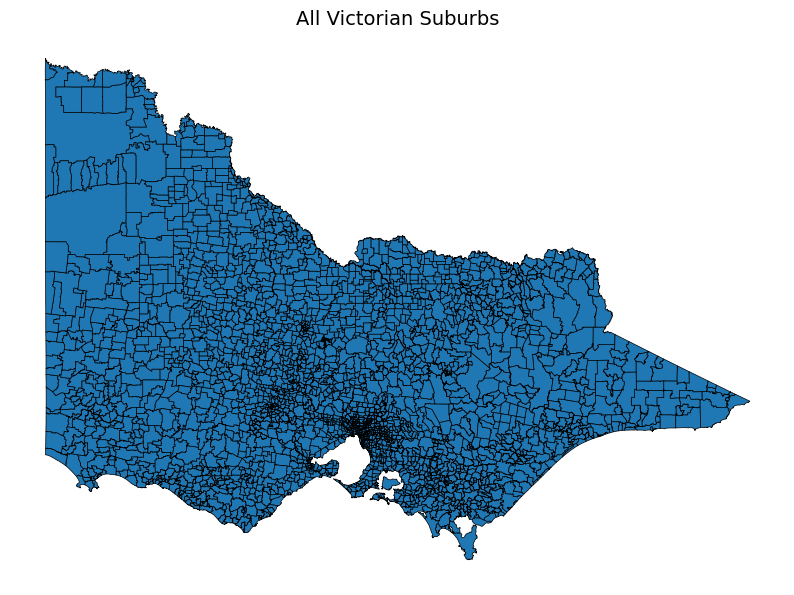

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

suburb_df.plot(ax=ax, edgecolor='black', linewidth=0.5)

ax.set_title("All Victorian Suburbs", fontsize=14)
ax.set_axis_off()

plt.show()
